### Architecture Choice & Justification

- To build this agent, I will use a LangGraph StateGraph implementing a ReAct (Reasoning and Acting) hybrid pattern.

### Design Pattern:
- Classifier Node: Analyzes the ticket text to extract category, priority, and confidence score.
- KB Search Tool Node: Queries the mock knowledge base for troubleshooting steps.
- Decision/Router Node: Evaluates confidence. If below a threshold (‭$< 0.75$‬), it triggers a interrupt() for human review. If high, it proceeds to draft the email.
- Email Drafting Node: Formulates the final response.


In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [2]:
import operator
from typing import Annotated, List, Literal, TypedDict
from langchain_core.messages import BaseMessage, HumanMessage, ToolMessage
from langchain_core.tools import tool
from langchain_openai import ChatOpenAI
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from pydantic import BaseModel, Field

In [3]:
# -----------------------------------------------------------------
# 1. State Definition
# -----------------------------------------------------------------


class SupportState(TypedDict):
  messages: Annotated[List[BaseMessage], operator.add]
  ticket_text: str
  category: str
  priority: str
  confidence: float
  kb_results: str
  drafted_resolution: str
  escalated: bool

In [4]:
# -----------------------------------------------------------------
# 2. State Definition
# -----------------------------------------------------------------

@tool
def query_knowledge_base(query: str) -> str:
    """Queries the IT support knowledge base for known resolutions."""

    # Mock knowledge base database
    kb = {
      "vpn": (
          "Error 807: Ensure your firewall allows UDP ports 500 and 4500. Re-install the GlobalProtect client if issues persist."
      ),
      "password": (
          "To reset a corporate password, navigate to auth.internal.corp/reset using your hardware token."
      ),
      "printer": (
          "Printer offline: Restart the print spooler service on Windows or re-add the printer via CUPS on macOS."
      ),
    }
    query_lower = query.lower()
    for key, resolution in kb.items():
        if key in query_lower:
            return f"[KB Match Found]: {resolution}"
    return "[KB Match Found]: No direct match found. General troubleshooting required: restart device and submit network logs."


In [5]:
tools = [query_knowledge_base]

In [6]:
# -----------------------------------------------------------------
# 3. Structured Outputs for Classification
# -----------------------------------------------------------------

class TicketAnalysis(BaseModel):
    category: Literal["VPN", "Password", "Printer", "Hardware", "Other"] = Field(description="The primary category of the IT issue.")
    priority: Literal["Low", "Medium", "High", "Critical"] = Field(description="Business priority based on impact.")
    confidence: float = Field(
      description=(
          "Agent confidence score between 0.0 and 1.0 in its classification and"
          " understanding."
      )
  )

In [8]:
# -----------------------------------------------------------------
# 4. Graph Nodes
# -----------------------------------------------------------------

llm = ChatOpenAI(model="gpt-4o", temperature=0)

def classify_ticket(state: SupportState):
    print(f"\n[LOG: Reason Trace] Step 1: Analyzing ticket text: '{state['ticket_text']}'")
    prompt = f"""Analyze the following IT support ticket: "{state['ticket_text']}" Classify its category, priority, and assign a confidence score. """
    structured_llm = llm.with_structured_output(TicketAnalysis)
    result: TicketAnalysis = structured_llm.invoke(prompt)
    print(f"[LOG: Reason Trace] Classified as Category={result.category}, Priority={result.priority}, Confidence={result.confidence}")
    return {
        "category": result.category,
        "priority": result.priority,
        "confidence": result.confidence
    }

def kb_lookup_node(state: SupportState):
  print(
      f"[LOG: Reason Trace] Step 2: Querying Knowledge Base for category: {state['category']}"
  )
  resolution = query_knowledge_base.invoke(state["ticket_text"])
  print(f"[LOG: Reason Trace] KB Retrieval Result: {resolution}")
  return {"kb_results": resolution}

def human_review_node(state: SupportState):
  print(
      "[LOG: Reason Trace] Step 3: Confidence below threshold (0.75)."
      " Triggering Human-in-the-Loop Interrupt."
  )

  # Interrupt execution and ask human for guidance/override
  human_input = interrupt({
      "question": (
          "Agent confidence is low. Please review ticket, KB results, and"
          " provide guidance or approved resolution text."
      ),
      "ticket": state["ticket_text"],
      "category": state["category"],
      "kb_results": state["kb_results"],
  })

  print(f"[LOG: Reason Trace] Resumed with human input: {human_input}")
  return {
      "drafted_resolution": human_input.get(
          "approved_resolution", "Escalated to Tier 2 Support per human review."
      ),
      "escalated": human_input.get("escalated", True),
  }

def draft_resolution_node(state: SupportState):
  print(
      "[LOG: Reason Trace] Step 3 (Auto): Confidence acceptable. Drafting"
      " resolution email."
  )
  prompt = f"""
    Draft a polite, professional IT support resolution email to the user.
    Issue: {state['ticket_text']}
    Category: {state['category']}
    Knowledge Base Info: {state['kb_results']}
    """
  response = llm.invoke(prompt)
  print(f"[LOG: Reason Trace] Drafted Email:\n{response.content}")
  return {"drafted_resolution": response.content, "escalated": False}

def router_condition(
    state: SupportState,
) -> Literal["kb_lookup_node", "human_review_node"]:
  # We can route right after classification to KB, and then evaluate confidence
  return "kb_lookup_node"


def confidence_router(
    state: SupportState,
) -> Literal["human_review_node", "draft_resolution_node"]:
  if state["confidence"] < 0.75:
    return "human_review_node"
  return "draft_resolution_node"


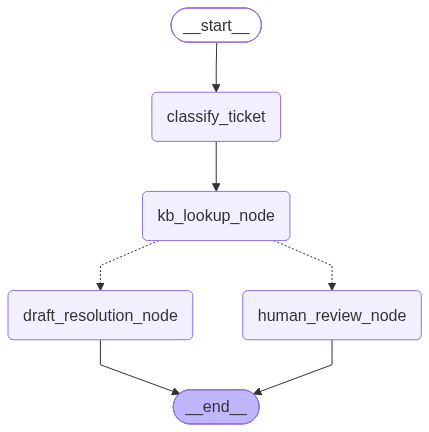

In [10]:
# -----------------------------------------------------------------
# 5. Build StateGraph
# -----------------------------------------------------------------

workflow = StateGraph(SupportState)

workflow.add_node("classify_ticket", classify_ticket)
workflow.add_node("kb_lookup_node", kb_lookup_node)
workflow.add_node("human_review_node", human_review_node)
workflow.add_node("draft_resolution_node", draft_resolution_node)

# Define edges
workflow.add_edge(START, "classify_ticket")
workflow.add_edge("classify_ticket", "kb_lookup_node")
workflow.add_conditional_edges(
    "kb_lookup_node",
    confidence_router,
    {
        "human_review_node": "human_review_node",
        "draft_resolution_node": "draft_resolution_node"
    }
)
workflow.add_edge("human_review_node", END)
workflow.add_edge("draft_resolution_node", END)

from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()
app = workflow.compile(checkpointer=memory)

app

In [ ]:
# Configuration for thread tracking
import uuid
config = {"configurable": {"thread_id": str(uuid.uuid4())}}

# Test Input 1: Clear query (High confidence -> Auto-draft email)
initial_state = {
    "ticket_text": (
        "I am getting Error 807 when trying to connect to the corporate VPN from"
        " home."
    ),
    "messages": [],
}


In [15]:
print("=== RUNNING IT SUPPORT AGENT ===")
for event in app.stream(initial_state, config):
  print(f"Event node processed: {list(event.keys())}")

# Check current state/interrupt status
state_snapshot = app.get_state(config)
if state_snapshot.next:
  print("\n--- GRAPH PAUSED FOR HUMAN INTERVENTION ---")

=== RUNNING IT SUPPORT AGENT ===

[LOG: Reason Trace] Step 1: Analyzing ticket text: 'I am getting Error langchain error home.'
[LOG: Reason Trace] Classified as Category=Other, Priority=Medium, Confidence=0.75
Event node processed: ['classify_ticket']
[LOG: Reason Trace] Step 2: Querying Knowledge Base for category: Other
[LOG: Reason Trace] KB Retrieval Result: [KB Match Found]: No direct match found. General troubleshooting required: restart device and submit network logs.
Event node processed: ['kb_lookup_node']
[LOG: Reason Trace] Step 3 (Auto): Confidence acceptable. Drafting resolution email.
[LOG: Reason Trace] Drafted Email:
Subject: Resolution for Your IT Support Request - Error Langchain Error Home

Dear [User's Name],

I hope this message finds you well. Thank you for reaching out to our IT support team regarding the issue you are experiencing with the "Error langchain error home."

While we do not have a direct match for this specific error in our knowledge base, we recomm

In [18]:
import uuid
from langgraph.types import Command

# Use a fresh thread ID for this test
config = {"configurable": {"thread_id": "jupyter-support-thread-low-conf"}}

# 1. Update the classification function temporarily to force low confidence for testing,
# OR use text that confuses the model completely:
initial_state_low_confidence = {
    "ticket_text": (
        "The recursive metaphysical quantum flux capacitor is singing blue"
        " melodies through the toaster matrix."
    ),
    "messages": [],
}

print("=== RUNNING AGENT TO FORCE LOW CONFIDENCE / INTERRUPT ===")
for event in app.stream(initial_state_low_confidence, config):
  print(f"Event node processed: {list(event.keys())}")

=== RUNNING AGENT TO FORCE LOW CONFIDENCE / INTERRUPT ===

[LOG: Reason Trace] Step 1: Analyzing ticket text: 'The recursive metaphysical quantum flux capacitor is singing blue melodies through the toaster matrix.'
[LOG: Reason Trace] Classified as Category=Other, Priority=Low, Confidence=0.3
Event node processed: ['classify_ticket']
[LOG: Reason Trace] Step 2: Querying Knowledge Base for category: Other
[LOG: Reason Trace] KB Retrieval Result: [KB Match Found]: No direct match found. General troubleshooting required: restart device and submit network logs.
Event node processed: ['kb_lookup_node']
[LOG: Reason Trace] Step 3: Confidence below threshold (0.75). Triggering Human-in-the-Loop Interrupt.
Event node processed: ['__interrupt__']


In [19]:
state_snapshot = app.get_state(config)

if state_snapshot.next:
  print("--- GRAPH IS SUCCESSFULLY PAUSED FOR INTERRUPT ---")
  interrupt_payload = state_snapshot.tasks[0].interrupts[0].value
  print("\n[HUMAN PROMPT RECEIVED]:")
  import pprint

  pprint.pprint(interrupt_payload)
else:
  print(
      "Still passed through! Let's check what confidence score the LLM"
      " generated."
  )

--- GRAPH IS SUCCESSFULLY PAUSED FOR INTERRUPT ---

[HUMAN PROMPT RECEIVED]:
{'category': 'Other',
 'kb_results': '[KB Match Found]: No direct match found. General '
               'troubleshooting required: restart device and submit network '
               'logs.',
 'question': 'Agent confidence is low. Please review ticket, KB results, and '
             'provide guidance or approved resolution text.',
 'ticket': 'The recursive metaphysical quantum flux capacitor is singing blue '
           'melodies through the toaster matrix.'}


In [20]:
# Define what the human wants to reply/override with
human_response = {
    "approved_resolution": (
        "WARNING: Unplug your system immediately and bring it to the IT"
        " hardware desk on Floor 3. Do not attempt to turn it back on."
    ),
    "escalated": True,
}

print("=== RESUMING GRAPH WITH HUMAN INPUT ===")
resume_output = app.invoke(Command(resume=human_response), config)

print("\n=== FINAL OUTPUT AFTER RESUMPTION ===")
print(resume_output)

=== RESUMING GRAPH WITH HUMAN INPUT ===
[LOG: Reason Trace] Step 3: Confidence below threshold (0.75). Triggering Human-in-the-Loop Interrupt.
[LOG: Reason Trace] Resumed with human input: {'approved_resolution': 'WARNING: Unplug your system immediately and bring it to the IT hardware desk on Floor 3. Do not attempt to turn it back on.', 'escalated': True}

=== FINAL OUTPUT AFTER RESUMPTION ===
{'messages': [], 'ticket_text': 'The recursive metaphysical quantum flux capacitor is singing blue melodies through the toaster matrix.', 'category': 'Other', 'priority': 'Low', 'confidence': 0.3, 'kb_results': '[KB Match Found]: No direct match found. General troubleshooting required: restart device and submit network logs.', 'drafted_resolution': 'WARNING: Unplug your system immediately and bring it to the IT hardware desk on Floor 3. Do not attempt to turn it back on.', 'escalated': True}
